In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 200
# Dark Mode Plots
plt.style.use('dark_background')
import corner
import ast

In [41]:
# Make the corner plot for the MCMC results
system_name = 'J0259'
model_ver = 'sie'
mcmc_samples_path = f'../{system_name}/mcmc/{model_ver}_mcmc.dat'
samples = pd.read_csv(mcmc_samples_path, delim_whitespace=True, header=None, names=['chi2', 'vel_disp', 'x', 'y', 'ellip', 'pa' ])


In [42]:
samples

,chi2,vel_disp,x,y,ellip,pa
0,14.72398,245.1212,0.049760,0.699939,0.337817,-19.45345
1,14.94013,245.1252,0.048996,0.699285,0.337790,-19.53195
2,17.07752,245.1927,0.048035,0.694296,0.340514,-19.46043
3,15.23235,245.1443,0.047951,0.698996,0.340754,-19.48901
4,17.85221,245.1501,0.046465,0.702282,0.343830,-19.49375
...,...,...,...,...,...,...
3563,19.86404,244.5158,0.049180,0.700912,0.351038,-19.38358
3564,23.45070,244.5502,0.059161,0.697260,0.359407,-19.48823
3565,23.04065,244.5197,0.052832,0.691698,0.352424,-19.52197
3566,21.74916,244.5234,0.049571,0.695048,0.352534,-19.66303


In [43]:
masked_samples = samples.drop(columns=['chi2']).to_numpy()

In [44]:
# # Masked Samples with no accept column
# masked_samples = samples[samples['accept'] == 'accept'].copy()
# masked_samples = masked_samples.drop(columns=['accept', 'chi2']).to_numpy()
# masked_samples

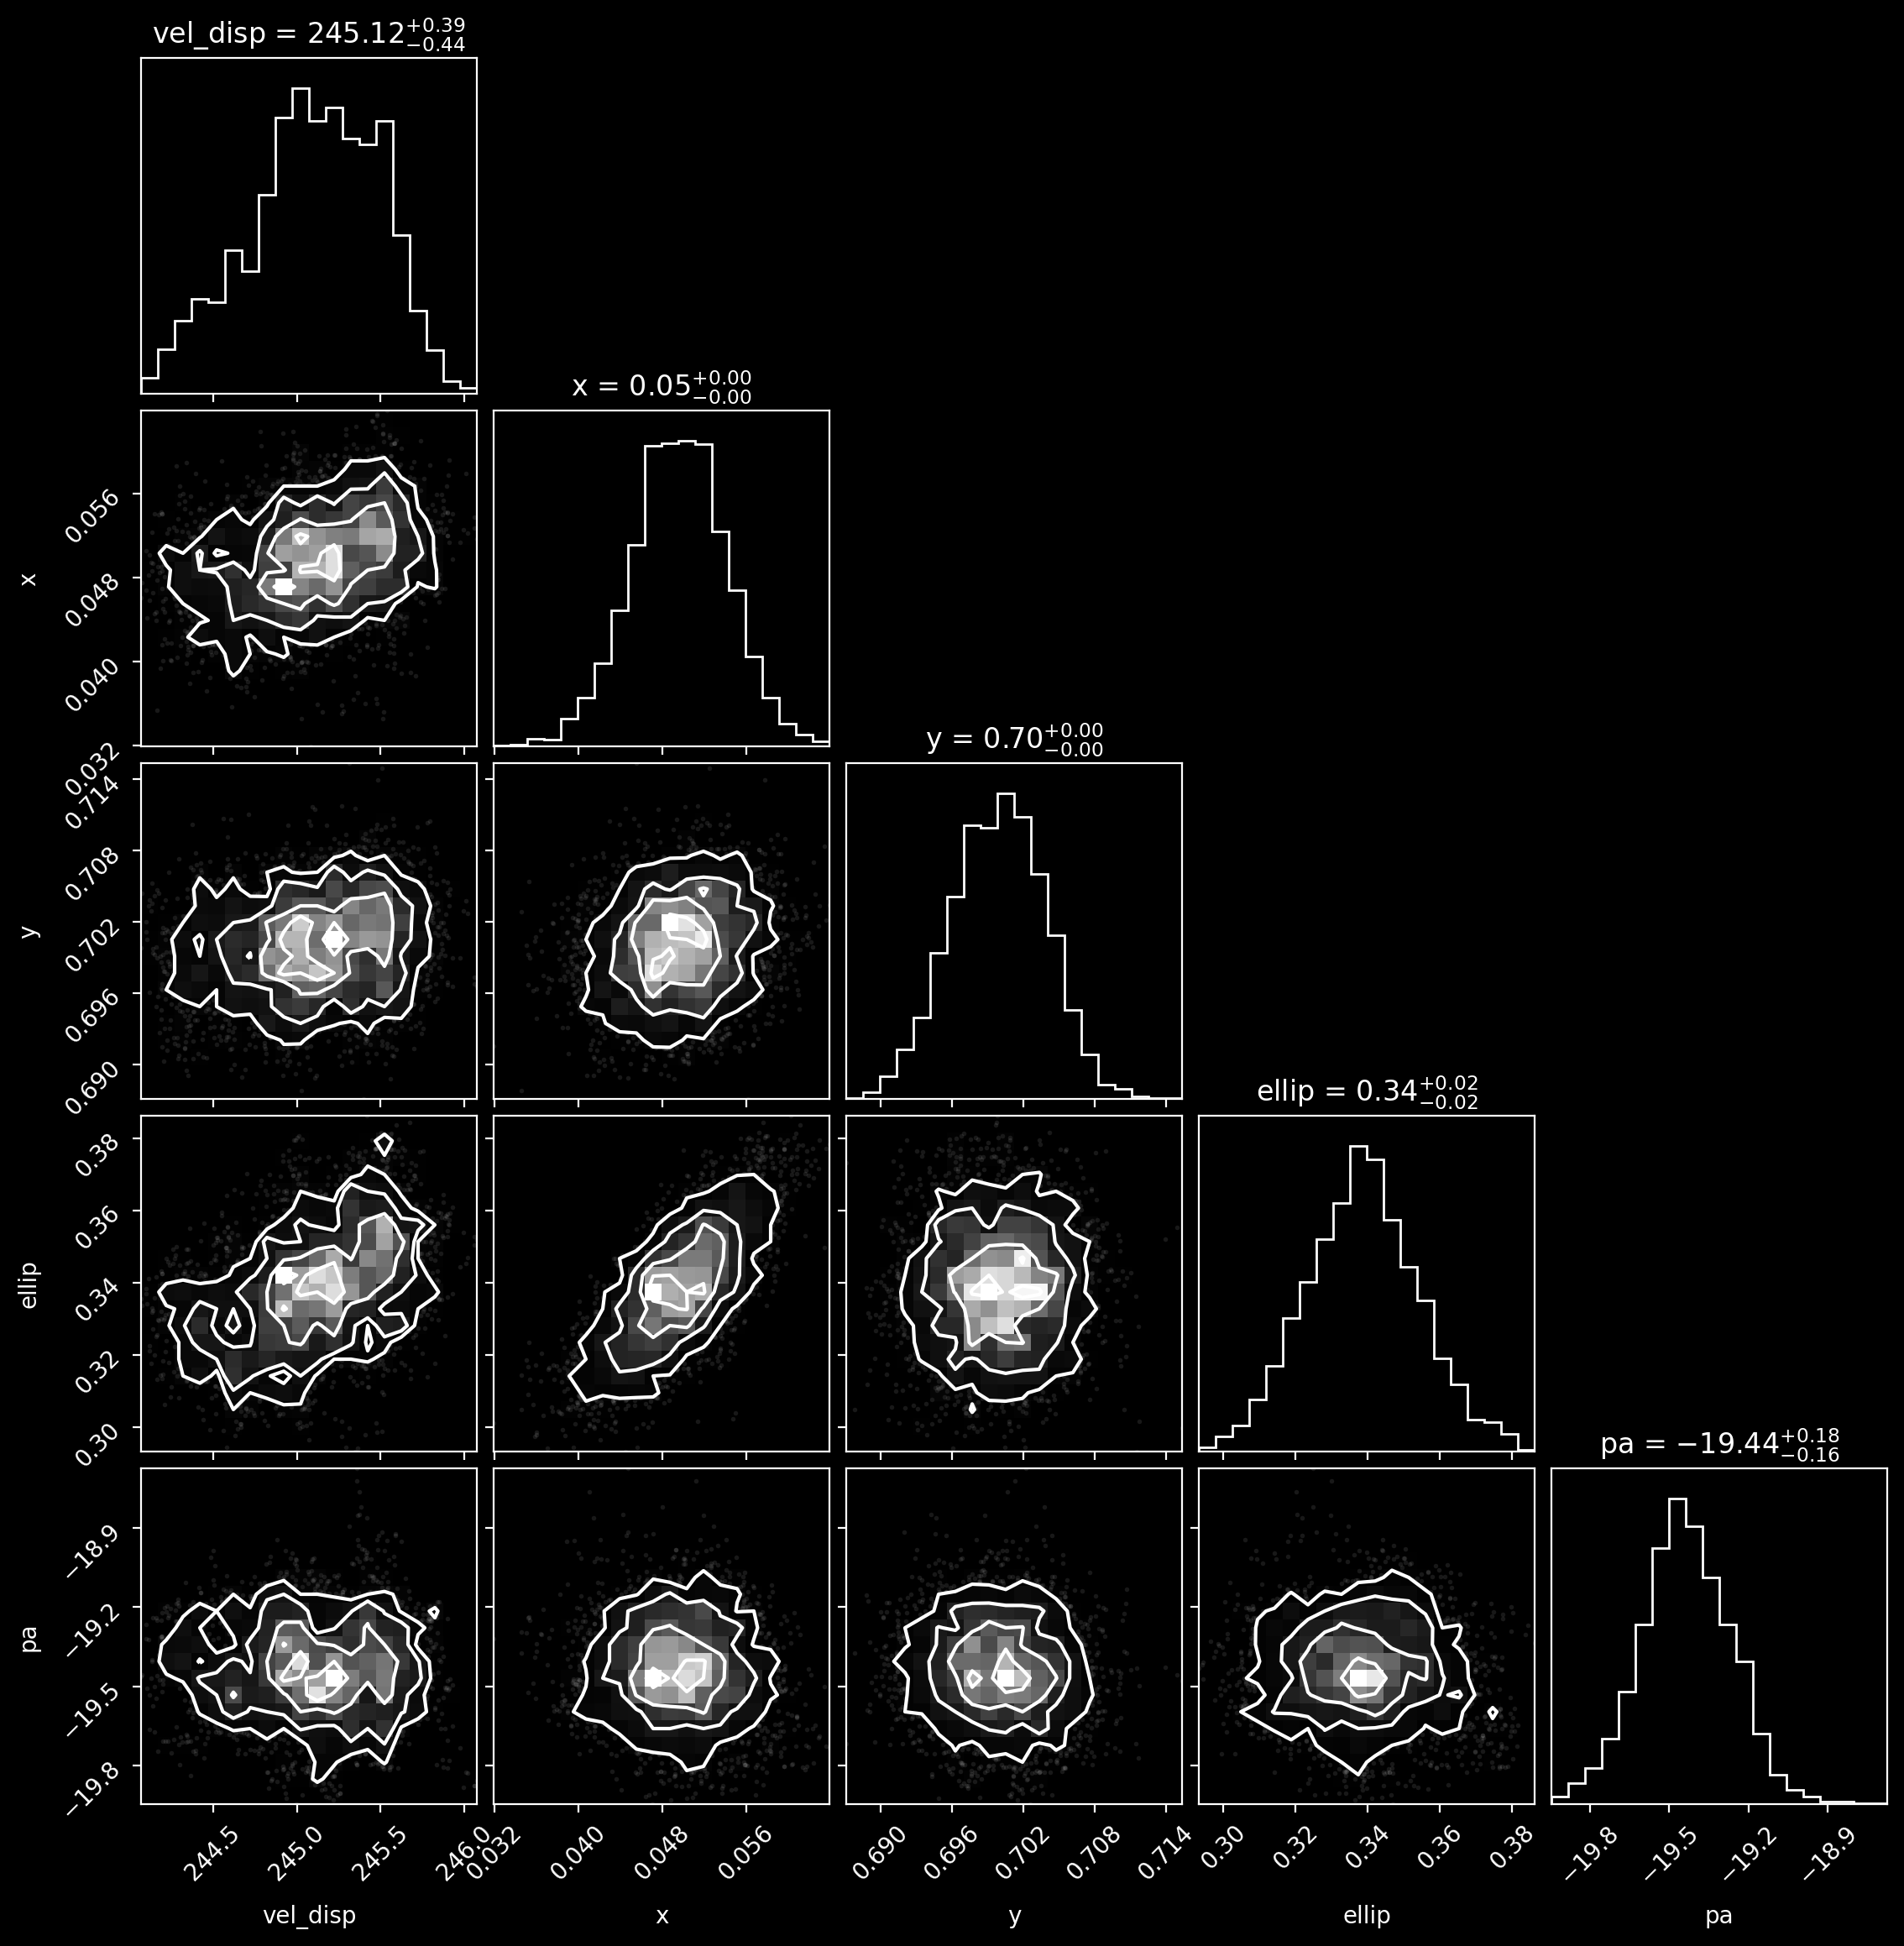

In [45]:
# Remove the first column when loading the samples, as it is the accepted/rejected column
labels = ['vel_disp', 'x', 'y', 'ellip', 'pa']
fig = corner.corner(masked_samples, labels=labels, show_titles=True)
plt.savefig(f'../{system_name}/mcmc/{model_ver}_corner.png')